# CNN 混凝土裂缝识别复现

本 Notebook 复现实验报告中的 ConcreteCrackCNN，并针对当前 SDNET2018 目录结构进行了可运行封装。代码按实验流程拆分为独立区块，便于逐步运行和修改。

> 重要修正：训练目录为 CD/UD，测试目录为 CP/UP。这里显式规定 `C* = cracked(1)`、`U* = uncracked(0)`，避免原代码将无裂缝类别误当作 Recall/F1 的正类。
        {
            "cell_type": "code",
            "id": "#VSC-8b03e171",
            "metadata": {
                "language": "python"
            },
            "source": [
                "last_checkpoint = {",
                "    'model_state_dict': model.state_dict(),",
                "    'architecture': 'ConcreteCrackCNN',",
                "    'class_names': list(CLASS_NAMES),",
                "    'positive_class': 'cracked',",
                "    'image_size': [224, 224],",
                "    'normalization': {",
                "        'mean': [0.485, 0.456, 0.406],",
                "        'std': [0.229, 0.224, 0.225],",
                "    },",
                "    'loss': 'CrossEntropyLoss',",
                "    'class_counts': class_counts.tolist(),",
                "    'class_weights': class_weights.tolist(),",
                "    'epoch': EPOCHS,",
                "}",
                "torch.save(last_checkpoint, OUTPUT_DIR / 'model_last.pt')",
                "",
                "config = {",
                "    'experiment': 'group_validation',",
                "    'model': 'ConcreteCrackCNN',",
                "    'loss': 'weighted_cross_entropy',",
                "    'quick_run': QUICK_RUN,",
                "    'epochs': EPOCHS,",
                "    'batch_size': BATCH_SIZE,",
                "    'learning_rate': LEARNING_RATE,",
                "    'device': str(device),",
                "    'class_weights': class_weights.tolist(),",
                "}",
                "(OUTPUT_DIR / 'config.json').write_text(",
                "    json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8'",
                ")",
                "",
                "split = {",
                "    'train_count': len(train_indices),",
                "    'validation_count': len(val_indices),",
                "    'test_count': len(test_data),",
                "    'train_labels': count_labels(train_indices),",
                "    'validation_labels': count_labels(val_indices),",
                "    'test_labels': summarize(test_full),",
                "}",
                "(OUTPUT_DIR / 'split.json').write_text(",
                "    json.dumps(split, ensure_ascii=False, indent=2), encoding='utf-8'",
                ")",
                "",
                "(OUTPUT_DIR / 'history.json').write_text(",
                "    json.dumps({",
                "        'history': history,",
                "        'best_epoch': best_epoch,",
                "        'best_val_f1': best_val_f1,",
                "        'elapsed_seconds': elapsed_seconds,",
                "    }, ensure_ascii=False, indent=2), encoding='utf-8'",
                ")",
                "print('Saved:', OUTPUT_DIR / 'model_best.pt')",
                "print('Saved:', OUTPUT_DIR / 'model_last.pt')",
                "print('Saved:', OUTPUT_DIR / 'config.json')",
                "print('Saved:', OUTPUT_DIR / 'split.json')",
                "print('Saved:', OUTPUT_DIR / 'history.json')"
            ]
        },
    EPOCHS = 10
    BATCH_SIZE = 32
    MAX_TRAIN_SAMPLES = None
    MAX_TEST_SAMPLES = None
    MAX_TRAIN_BATCHES = None

assert (DATA_ROOT / 'train').is_dir(), f'找不到训练集：{DATA_ROOT / "train"}'
assert (DATA_ROOT / 'test').is_dir(), f'找不到测试集：{DATA_ROOT / "test"}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Data root:', DATA_ROOT)
print('Output directory:', OUTPUT_DIR)
print('Quick run:', QUICK_RUN)

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = (PROJECT_ROOT / 'SDNET2018' / 'SDNET2018').resolve()
OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / 'group_validation_flip'

QUICK_RUN = False
SEED = 42
LEARNING_RATE = 0.0001
BATCH_SIZE = 32
EPOCHS = 30
NUM_WORKERS = 0
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None
MAX_TRAIN_BATCHES = None

assert (DATA_ROOT / 'train').is_dir(), f'找不到训练集：{DATA_ROOT / "train"}'
assert (DATA_ROOT / 'test').is_dir(), f'找不到测试集：{DATA_ROOT / "test"}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Data root:', DATA_ROOT)
print('Output directory:', OUTPUT_DIR)
print('Learning rate:', LEARNING_RATE)
print('Epochs:', EPOCHS)

Data root: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\SDNET2018\SDNET2018
Output directory: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip
Learning rate: 0.0001
Epochs: 30


## 3 随机种子与计算设备

In [95]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 4 图像预处理与标签映射

预处理保持与报告一致：缩放至 224×224、转 Tensor，并使用 ImageNet 均值和标准差归一化。

In [90]:
fixed_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 验证、测试和单张预测统一使用固定预处理
transform = fixed_transform


def semantic_label(folder_name):
    prefix = folder_name.strip().upper()[:1]
    if prefix == 'C':
        return 1  # cracked
    if prefix == 'U':
        return 0  # uncracked
    raise ValueError(f'不支持的类别目录：{folder_name}')


class CrackImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(str(root), transform=transform)
        remapped = [
            (path, semantic_label(Path(path).parent.name))
            for path, _ in self.samples
        ]
        self.samples = remapped
        self.imgs = remapped
        self.targets = [target for _, target in remapped]
        self.classes = list(CLASS_NAMES)
        self.class_to_idx = {'uncracked': 0, 'cracked': 1}

## 5 加载并检查数据集

In [91]:
train_full = CrackImageFolder(DATA_ROOT / 'train', transform=fixed_transform)
train_aug_full = CrackImageFolder(DATA_ROOT / 'train', transform=train_transform)
test_full = CrackImageFolder(DATA_ROOT / 'test', transform=fixed_transform)

assert [path for path, _ in train_full.samples] == [
    path for path, _ in train_aug_full.samples
], '固定预处理和增强预处理的图片顺序不一致'


def summarize(dataset):
    counts = Counter(dataset.targets)
    return {CLASS_NAMES[index]: counts[index] for index in range(2)}

print('Train:', summarize(train_full), 'total =', len(train_full))
print('Train augmented:', summarize(train_aug_full), 'total =', len(train_aug_full))
print('Test :', summarize(test_full), 'total =', len(test_full))
print('Positive class for Recall/F1: cracked(1)')

Train: {'uncracked': 11595, 'cracked': 2025} total = 13620
Train augmented: {'uncracked': 11595, 'cracked': 2025} total = 13620
Test : {'uncracked': 21726, 'cracked': 2608} total = 24334
Positive class for Recall/F1: cracked(1)


In [59]:
for label, name in enumerate(CLASS_NAMES):
    filenames = [
        Path(path).name
        for path, target in train_full.samples
        if target == label
    ]
    print(name, filenames[:10])

uncracked ['7001-1.jpg', '7001-10.jpg', '7001-100.jpg', '7001-101.jpg', '7001-102.jpg', '7001-103.jpg', '7001-104.jpg', '7001-105.jpg', '7001-106.jpg', '7001-107.jpg']
cracked ['7001-115.jpg', '7001-139.jpg', '7001-151.jpg', '7001-157.jpg', '7001-169.jpg', '7001-17.jpg', '7001-173.jpg', '7001-178.jpg', '7001-187.jpg', '7001-2.jpg']


In [92]:
# 1. 按文件名前缀分组
groups = {}

for index, (path, label) in enumerate(train_full.samples):
    group_id = Path(path).stem.split("-")[0]
    groups.setdefault(group_id, []).append(index)

# 2. 打乱组的顺序，抽取约 20% 的组作为验证集
group_ids = sorted(groups)
random.Random(SEED).shuffle(group_ids)

assert len(group_ids) >= 2, "分组数量不足，无法划分"

val_group_count = min(
    len(group_ids) - 1,
    max(1, round(len(group_ids) * 0.2))
)

val_groups = set(group_ids[:val_group_count])

# 3. 分别记录训练图片和验证图片的编号
train_indices = []
val_indices = []

for group_id, indices in groups.items():
    if group_id in val_groups:
        val_indices.extend(indices)
    else:
        train_indices.extend(indices)

# 4. 检查各部分的类别数量
def count_labels(indices):
    counts = Counter(train_full.targets[i] for i in indices)
    return {CLASS_NAMES[label]: counts[label] for label in range(2)}

print("总分组数：", len(groups))
print("验证集分组数：", len(val_groups))
print("训练集图片数：", len(train_indices), count_labels(train_indices))
print("验证集图片数：", len(val_indices), count_labels(val_indices))

assert set(train_indices).isdisjoint(val_indices)
assert len(train_indices) + len(val_indices) == len(train_full)

for indices in (train_indices, val_indices):
    assert {train_full.targets[i] for i in indices} == {0, 1}, \
        "某个集合缺少一个类别，需要调整分组划分"

总分组数： 54
验证集分组数： 11
训练集图片数： 10848 {'uncracked': 9250, 'cracked': 1598}
验证集图片数： 2772 {'uncracked': 2345, 'cracked': 427}


## 6 构造 DataLoader

快速模式从两个类别中等量抽样，确保冒烟测试同时包含裂缝和无裂缝图像。完整模式直接使用全部数据。

In [93]:
# 训练使用翻转增强数据集，验证和测试使用固定预处理数据集
train_data = Subset(train_aug_full, train_indices)
val_data = Subset(train_full, val_indices)
test_data = test_full

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("参与训练：", len(train_loader.dataset))
print("用于验证：", len(val_loader.dataset))
print("用于测试：", len(test_loader.dataset))
print("训练预处理：水平翻转 + 垂直翻转")
print("验证/测试预处理：固定 Resize + ToTensor + Normalize")

参与训练： 10848
用于验证： 2772
用于测试： 24334
训练预处理：水平翻转 + 垂直翻转
验证/测试预处理：固定 Resize + ToTensor + Normalize


## 7 定义 ConcreteCrackCNN

网络结构与实验报告保持一致。输出层直接产生 logits，训练时交给 CrossEntropyLoss，不在模型内部额外使用 Softmax。

In [96]:
class ConcreteCrackCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.relu3(self.fc1(x))
        return self.fc2(x)


model = ConcreteCrackCNN().to(device)
# 类别权重只根据实际参与训练的图片计算
train_labels = [train_full.targets[i] for i in train_indices]

class_counts = torch.bincount(
    torch.tensor(train_labels),
    minlength=2
).float()
class_weights = class_counts.sum() / (2 * class_counts)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))
print('Class counts:', class_counts.tolist())
print('Class weights:', class_weights.tolist())

ConcreteCrackCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
Trainable parameters: 12850530
Class counts: [9250.0, 1598.0]
Class weights: [0.5863783955574036, 3.394242763519287]


## 8 定义训练函数

In [74]:
def train_one_epoch(model, loader, criterion, optimizer, device, max_batches=None):
    model.train()
    weighted_loss_sum = 0.0
    weight_sum = 0.0
    for batch_index, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        batch_weights = (
            criterion.weight[labels]
            if criterion.weight is not None
            else torch.ones_like(labels, dtype=torch.float32)
        )
        weighted_loss_sum += loss.item() * batch_weights.sum().item()
        weight_sum += batch_weights.sum().item()
    return weighted_loss_sum / weight_sum


@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    weighted_loss_sum = 0.0
    weight_sum = 0.0
    targets, predictions = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        batch_weights = (
            criterion.weight[labels]
            if criterion.weight is not None
            else torch.ones_like(labels, dtype=torch.float32)
        )
        weighted_loss_sum += loss.item() * batch_weights.sum().item()
        weight_sum += batch_weights.sum().item()
        predicted = logits.argmax(dim=1)
        targets.extend(labels.cpu().tolist())
        predictions.extend(predicted.cpu().tolist())

    true_positive = sum(t == 1 and p == 1 for t, p in zip(targets, predictions))
    false_positive = sum(t == 0 and p == 1 for t, p in zip(targets, predictions))
    false_negative = sum(t == 1 and p == 0 for t, p in zip(targets, predictions))
    true_negative = sum(t == 0 and p == 0 for t, p in zip(targets, predictions))

    def safe_divide(numerator, denominator):
        return numerator / denominator if denominator else 0.0

    precision = safe_divide(true_positive, true_positive + false_positive)
    recall = safe_divide(true_positive, true_positive + false_negative)
    specificity = safe_divide(true_negative, true_negative + false_positive)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    metrics = {
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'balanced_accuracy': (recall + specificity) / 2,
        'true_positive': true_positive,
        'false_positive': false_positive,
        'false_negative': false_negative,
        'true_negative': true_negative,
    }
    return weighted_loss_sum / weight_sum, metrics

## 9 训练模型

In [97]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_specificity': [],
    'val_f1': [],
    'val_balanced_accuracy': [],
}
best_val_f1 = -1.0
best_epoch = 0
patience = 5
rounds_without_improvement = 0
started = time.perf_counter()

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device, MAX_TRAIN_BATCHES
    )
    val_loss, val_metrics = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_specificity'].append(val_metrics['specificity'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_balanced_accuracy'].append(val_metrics['balanced_accuracy'])

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'architecture': 'ConcreteCrackCNN',
        'class_names': list(CLASS_NAMES),
        'positive_class': 'cracked',
        'image_size': [224, 224],
        'normalization': {
            'mean': [0.485, 0.456, 0.406],
            'std': [0.229, 0.224, 0.225],
        },
        'loss': 'CrossEntropyLoss',
        'class_counts': class_counts.tolist(),
        'class_weights': class_weights.tolist(),
        'epoch': epoch + 1,
        'val_metrics': val_metrics,
    }
    torch.save(checkpoint, OUTPUT_DIR / 'model_last.pt')

    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch + 1
        rounds_without_improvement = 0
        torch.save(checkpoint, OUTPUT_DIR / 'model_best.pt')
    else:
        rounds_without_improvement += 1

    print(
        f"Epoch {epoch + 1}/{EPOCHS}, "
        f"Train Loss: {train_loss:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Precision: {val_metrics['precision']:.4f}, "
        f"Val Recall: {val_metrics['recall']:.4f}, "
        f"Val F1: {val_metrics['f1']:.4f}, "
        f"Val BA: {val_metrics['balanced_accuracy']:.4f}"
    )

    if rounds_without_improvement >= patience:
        print(f'Early stopping after {patience} rounds without validation F1 improvement.')
        break

elapsed_seconds = time.perf_counter() - started
epochs_ran = len(history['train_loss'])
print(f'Training time: {elapsed_seconds:.2f} seconds')
print(f'Epochs ran: {epochs_ran}')
print(f'Best epoch by validation F1: {best_epoch}')
print(f'Best validation F1: {best_val_f1:.4f}')

Epoch 1/30, Train Loss: 0.7026, Val Loss: 0.6812, Val Precision: 1.0000, Val Recall: 0.0070, Val F1: 0.0140, Val BA: 0.5035
Epoch 2/30, Train Loss: 0.6810, Val Loss: 0.6717, Val Precision: 0.2227, Val Recall: 0.6838, Val F1: 0.3360, Val BA: 0.6246
Epoch 3/30, Train Loss: 0.6709, Val Loss: 0.6584, Val Precision: 0.2479, Val Recall: 0.6183, Val F1: 0.3539, Val BA: 0.6383
Epoch 4/30, Train Loss: 0.6630, Val Loss: 0.6599, Val Precision: 0.3724, Val Recall: 0.3794, Val F1: 0.3759, Val BA: 0.6315
Epoch 5/30, Train Loss: 0.6560, Val Loss: 0.6721, Val Precision: 0.5865, Val Recall: 0.1827, Val F1: 0.2786, Val BA: 0.5796
Epoch 6/30, Train Loss: 0.6497, Val Loss: 0.6323, Val Precision: 0.3141, Val Recall: 0.6370, Val F1: 0.4207, Val BA: 0.6918
Epoch 7/30, Train Loss: 0.6403, Val Loss: 0.6389, Val Precision: 0.2993, Val Recall: 0.6721, Val F1: 0.4141, Val BA: 0.6928
Epoch 8/30, Train Loss: 0.6383, Val Loss: 0.6316, Val Precision: 0.4673, Val Recall: 0.4356, Val F1: 0.4509, Val BA: 0.6726
Epoch 9/

KeyboardInterrupt: 

## 10 绘制训练损失

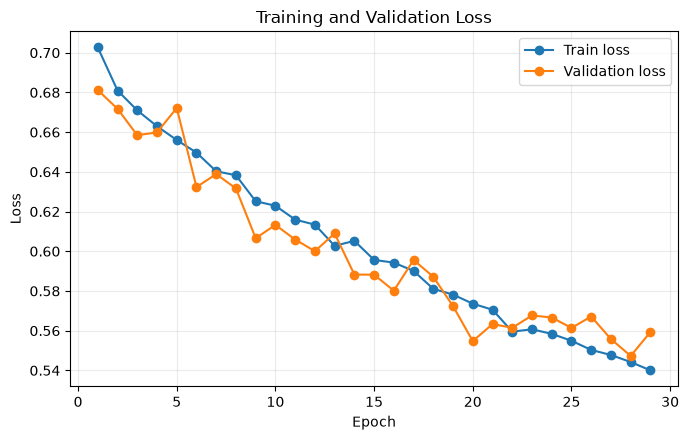

In [99]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], marker='o', label='Train loss')
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=160)
plt.show()

## 11 测试集评估

除报告中的 Accuracy、Recall 和 F1 外，同时输出 Precision、Specificity、Balanced Accuracy 与混淆矩阵计数。所有二分类指标均以裂缝类为正类。

In [54]:
@torch.inference_mode()
def collect_predictions(model, loader, device):
    model.eval()
    targets, predictions = [], []
    for images, labels in loader:
        logits = model(images.to(device))
        predicted = logits.argmax(dim=1).cpu()
        targets.extend(labels.tolist())
        predictions.extend(predicted.tolist())
    return targets, predictions


def safe_div(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def calculate_metrics(targets, predictions):
    tp = sum(t == 1 and p == 1 for t, p in zip(targets, predictions))
    fp = sum(t == 0 and p == 1 for t, p in zip(targets, predictions))
    fn = sum(t == 1 and p == 0 for t, p in zip(targets, predictions))
    tn = sum(t == 0 and p == 0 for t, p in zip(targets, predictions))
    accuracy = safe_div(tp + tn, len(targets))
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    specificity = safe_div(tn, tn + fp)
    f1 = safe_div(2 * precision * recall, precision + recall)
    return {
        'accuracy': accuracy,
        'balanced_accuracy': (recall + specificity) / 2,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'true_positive': tp,
        'false_positive': fp,
        'false_negative': fn,
        'true_negative': tn,
        'total': len(targets),
    }


targets, predictions = collect_predictions(model, test_loader, device)
metrics = calculate_metrics(targets, predictions)
for name, value in metrics.items():
    print(f'{name}: {value:.4f}' if isinstance(value, float) else f'{name}: {value}')

accuracy: 0.4601
balanced_accuracy: 0.5016
precision: 0.1077
recall: 0.5544
specificity: 0.4488
f1: 0.1804
true_positive: 1446
false_positive: 11976
false_negative: 1162
true_negative: 9750
total: 24334


## 12 保存模型与实验指标

In [100]:
best_index = best_epoch - 1
best_validation_metrics = {
    'precision': history['val_precision'][best_index],
    'recall': history['val_recall'][best_index],
    'specificity': history['val_specificity'][best_index],
    'f1': history['val_f1'][best_index],
    'balanced_accuracy': history['val_balanced_accuracy'][best_index],
}

epochs_ran = len(history['train_loss'])
last_checkpoint = {
    'model_state_dict': model.state_dict(),
    'architecture': 'ConcreteCrackCNN',
    'class_names': list(CLASS_NAMES),
    'positive_class': 'cracked',
    'image_size': [224, 224],
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225],
    },
    'loss': 'CrossEntropyLoss',
    'class_counts': class_counts.tolist(),
    'class_weights': class_weights.tolist(),
    'learning_rate': LEARNING_RATE,
    'epoch': epochs_ran,
    'augmentation': ['RandomHorizontalFlip', 'RandomVerticalFlip'],
}
torch.save(last_checkpoint, OUTPUT_DIR / 'model_last.pt')

config = {
    'experiment': 'group_validation_flip',
    'model': 'ConcreteCrackCNN',
    'loss': 'weighted_cross_entropy',
    'augmentation': ['RandomHorizontalFlip', 'RandomVerticalFlip'],
    'quick_run': QUICK_RUN,
    'epoch_limit': EPOCHS,
    'epochs_ran': epochs_ran,
    'early_stopping_patience': patience,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'device': str(device),
    'class_weights': class_weights.tolist(),
}
(OUTPUT_DIR / 'config.json').write_text(
    json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8'
)

split = {
    'train_count': len(train_indices),
    'validation_count': len(val_indices),
    'test_count': len(test_data),
    'train_labels': count_labels(train_indices),
    'validation_labels': count_labels(val_indices),
    'test_labels': summarize(test_full),
}
(OUTPUT_DIR / 'split.json').write_text(
    json.dumps(split, ensure_ascii=False, indent=2), encoding='utf-8'
)

(OUTPUT_DIR / 'history.json').write_text(
    json.dumps({
        'history': history,
        'best_epoch': best_epoch,
        'best_val_f1': best_val_f1,
        'epochs_ran': epochs_ran,
        'elapsed_seconds': elapsed_seconds,
    }, ensure_ascii=False, indent=2), encoding='utf-8'
)

metrics_summary = {
    'experiment': 'group_validation_flip',
    'best_epoch': best_epoch,
    'best_validation_metrics': best_validation_metrics,
    'epochs_ran': epochs_ran,
    'train_count': len(train_indices),
    'validation_count': len(val_indices),
    'test_count': len(test_data),
    'device': str(device),
}
(OUTPUT_DIR / 'metrics.json').write_text(
    json.dumps(metrics_summary, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Saved:', OUTPUT_DIR / 'model_best.pt')
print('Saved:', OUTPUT_DIR / 'model_last.pt')
print('Saved:', OUTPUT_DIR / 'config.json')
print('Saved:', OUTPUT_DIR / 'split.json')
print('Saved:', OUTPUT_DIR / 'history.json')
print('Saved:', OUTPUT_DIR / 'metrics.json')

Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\model_best.pt
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\model_last.pt
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\config.json
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\split.json
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\history.json
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\metrics.json


## 13 单张图像预测

Image: C:\Users\72758\Desktop\科研\download.jpg
Prediction: cracked
P(uncracked): 0.000000
P(cracked): 1.000000


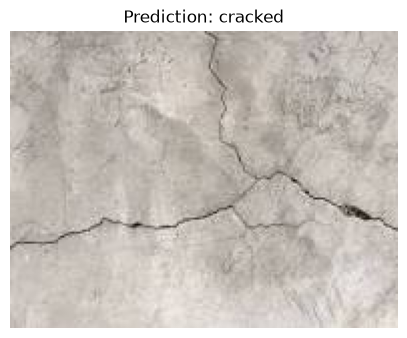

In [58]:
sample_path = r"C:\Users\72758\Desktop\科研\download.jpg"
with Image.open(sample_path) as image:
    rgb_image = image.convert('RGB')
    input_tensor = transform(rgb_image).unsqueeze(0).to(device)

model.eval()
with torch.inference_mode():
    probabilities = torch.softmax(model(input_tensor), dim=1)[0].cpu().numpy()

predicted_index = int(probabilities.argmax())
print('Image:', sample_path)
print('Prediction:', CLASS_NAMES[predicted_index])
print(f'P(uncracked): {probabilities[0]:.6f}')
print(f'P(cracked): {probabilities[1]:.6f}')

plt.figure(figsize=(5, 5))
plt.imshow(rgb_image)
plt.title(f'Prediction: {CLASS_NAMES[predicted_index]}')
plt.axis('off')
plt.show()

## 14 结果解释注意事项

1. 报告使用桥面图像训练、路面图像测试，测试结果包含跨构件域偏移影响。
2. 裂缝样本明显少于无裂缝样本，仅看 Accuracy 容易高估模型能力。
3. 快速模式只验证代码链路，不能作为正式实验结果。
4. 完整实验应同时报告裂缝类 Recall、Precision、F1、Balanced Accuracy 与混淆矩阵。

[train] loss: 0.682736
[train] metrics: {'precision': 0.0, 'recall': 0.0, 'specificity': 1.0, 'f1': 0.0, 'balanced_accuracy': 0.5, 'true_positive': 0, 'false_positive': 0, 'false_negative': 1598, 'true_negative': 9250}
[train] cracked probability overall:
  mean: 0.4725084761672377
  quantiles: [1.7509776977980963e-20, 0.4858190715312958, 0.4858190715312958, 0.4858190715312958, 0.4858190715312958]
  actual uncracked: count=9250, mean=0.470222, median=0.485819
  actual cracked: count=1598, mean=0.485741, median=0.485819
[validation] loss: 0.685995
[validation] metrics: {'precision': 0.0, 'recall': 0.0, 'specificity': 1.0, 'f1': 0.0, 'balanced_accuracy': 0.5, 'true_positive': 0, 'false_positive': 0, 'false_negative': 427, 'true_negative': 2345}
[validation] cracked probability overall:
  mean: 0.4754337030107568
  quantiles: [2.455177265091545e-19, 0.4858190715312958, 0.4858190715312958, 0.4858190715312958, 0.4858190715312958]
  actual uncracked: count=2345, mean=0.473544, median=0.48581

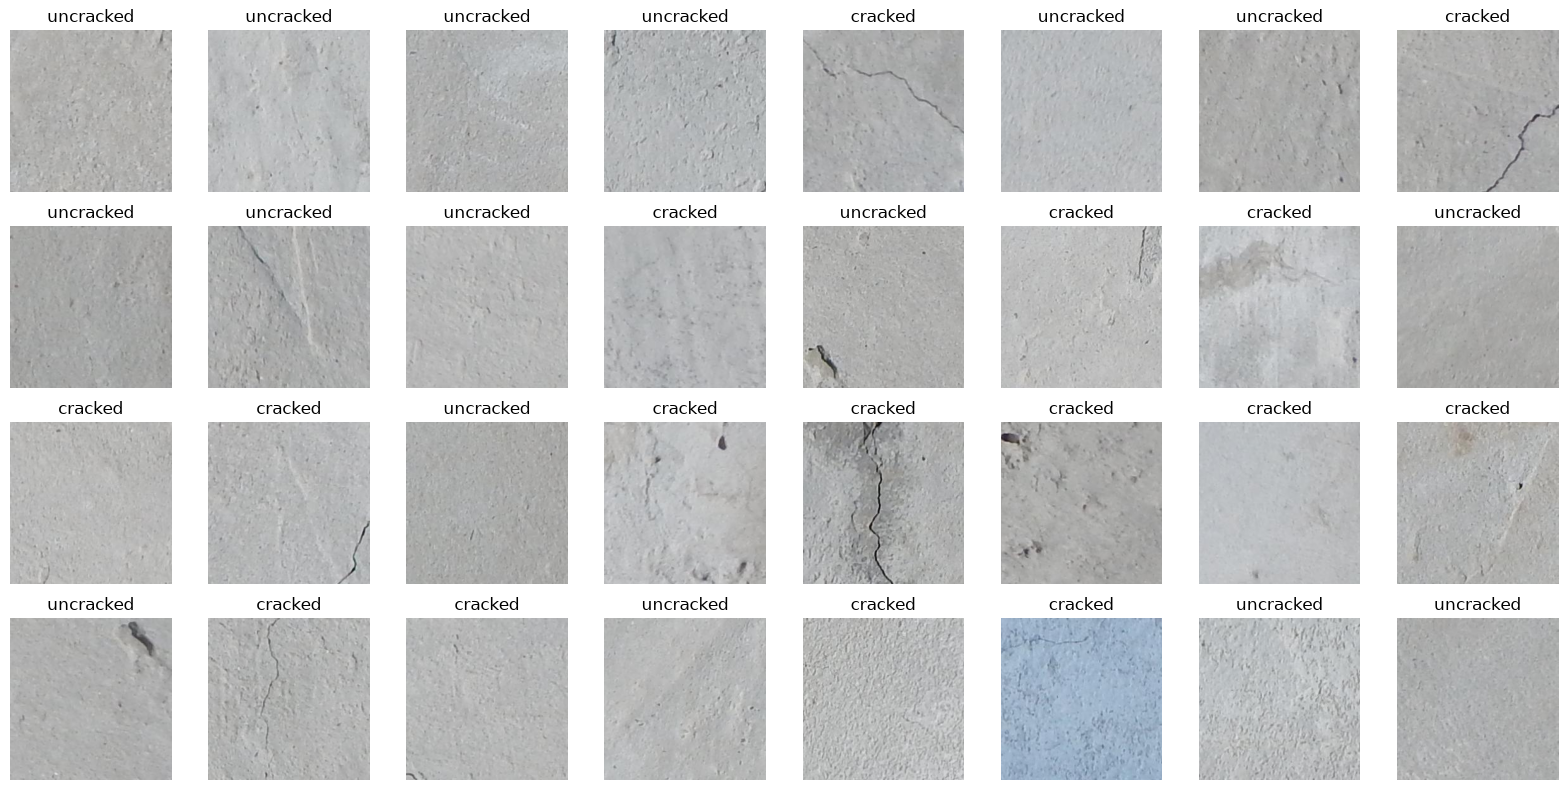

Fixed 32 samples repetition 1: {'repetition': 1, 'loss': 0.001697996980510652, 'precision': 1.0, 'recall': 1.0, 'specificity': 1.0, 'f1': 1.0, 'balanced_accuracy': 1.0, 'true_positive': 16, 'false_positive': 0, 'false_negative': 0, 'true_negative': 16}
Fixed 32 samples repetition 2: {'repetition': 2, 'loss': 0.01948591321706772, 'precision': 1.0, 'recall': 1.0, 'specificity': 1.0, 'f1': 1.0, 'balanced_accuracy': 1.0, 'true_positive': 16, 'false_positive': 0, 'false_negative': 0, 'true_negative': 16}
Fixed 32 samples repetition 3: {'repetition': 3, 'loss': 0.001886906917206943, 'precision': 1.0, 'recall': 1.0, 'specificity': 1.0, 'f1': 1.0, 'balanced_accuracy': 1.0, 'true_positive': 16, 'false_positive': 0, 'false_negative': 0, 'true_negative': 16}
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation\fixed_32_samples.png
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation\diagnostics.json


In [75]:
@torch.inference_mode()
def collect_probability_diagnostics(model, loader, device):
    model.eval()
    targets, predictions, cracked_probabilities = [], [], []
    for images, labels in loader:
        probabilities = torch.softmax(model(images.to(device)), dim=1)
        predicted = probabilities.argmax(dim=1).cpu()
        targets.extend(labels.tolist())
        predictions.extend(predicted.tolist())
        cracked_probabilities.extend(probabilities[:, 1].cpu().tolist())
    return targets, predictions, np.array(cracked_probabilities)


def print_split_diagnostics(name, loader):
    loss, split_metrics = evaluate(model, loader, criterion, device)
    targets, predictions, cracked_probabilities = collect_probability_diagnostics(
        model, loader, device
    )
    print(f'[{name}] loss: {loss:.6f}')
    print(f'[{name}] metrics: {split_metrics}')
    print(f'[{name}] cracked probability overall:')
    print('  mean:', float(cracked_probabilities.mean()))
    print('  quantiles:', np.quantile(cracked_probabilities, [0, 0.25, 0.5, 0.75, 1]).tolist())
    for label, class_name in enumerate(CLASS_NAMES):
        class_probabilities = cracked_probabilities[np.array(targets) == label]
        print(
            f'  actual {class_name}: count={len(class_probabilities)}, '
            f'mean={float(class_probabilities.mean()):.6f}, '
            f'median={float(np.median(class_probabilities)):.6f}'
        )


print_split_diagnostics('train', train_loader)
print_split_diagnostics('validation', val_loader)

label_indices = {
    label: [index for index in train_indices if train_full.targets[index] == label]
    for label in range(2)
}
rng = random.Random(SEED)
fixed_indices = []
for label in range(2):
    selected = label_indices[label].copy()
    rng.shuffle(selected)
    fixed_indices.extend(selected[:16])
rng.shuffle(fixed_indices)

fixed_data = Subset(train_full, fixed_indices)
fixed_loader = DataLoader(
    fixed_data,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
print('Fixed diagnostic labels:', Counter(train_full.targets[index] for index in fixed_indices))
print('Fixed diagnostic paths:')
for index in fixed_indices:
    print(CLASS_NAMES[train_full.targets[index]], train_full.samples[index][0])

figure, axes = plt.subplots(4, 8, figsize=(16, 8))
for axis, index in zip(axes.flat, fixed_indices):
    image_path, label = train_full.samples[index]
    with Image.open(image_path) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_title(CLASS_NAMES[label])
    axis.axis('off')
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'fixed_32_samples.png', dpi=160)
plt.show()

small_sample_results = []
for repetition in range(3):
    seed_everything(SEED + repetition)
    small_model = ConcreteCrackCNN().to(device)
    small_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    small_optimizer = optim.Adam(small_model.parameters(), lr=LEARNING_RATE)
    for _ in range(50):
        train_one_epoch(
            small_model,
            fixed_loader,
            small_criterion,
            small_optimizer,
            device,
        )
    small_loss, small_metrics = evaluate(
        small_model,
        fixed_loader,
        small_criterion,
        device,
    )
    result = {
        'repetition': repetition + 1,
        'loss': small_loss,
        **small_metrics,
    }
    small_sample_results.append(result)
    print(f'Fixed 32 samples repetition {repetition + 1}:', result)

(OUTPUT_DIR / 'diagnostics.json').write_text(
    json.dumps({'small_sample_results': small_sample_results}, indent=2),
    encoding='utf-8',
)
print('Saved:', OUTPUT_DIR / 'fixed_32_samples.png')
print('Saved:', OUTPUT_DIR / 'diagnostics.json')

In [82]:
def summarize_current_split(name, loader):
    loss, split_metrics = evaluate(model, loader, criterion, device)
    targets, predictions, cracked_probabilities = collect_probability_diagnostics(
        model, loader, device
    )
    summary = {
        'loss': loss,
        'metrics': split_metrics,
        'cracked_probability_mean': float(cracked_probabilities.mean()),
        'cracked_probability_std': float(cracked_probabilities.std()),
        'cracked_probability_quantiles': np.quantile(
            cracked_probabilities, [0, 0.25, 0.5, 0.75, 1]
        ).tolist(),
        'actual_uncracked_probability_mean': float(
            cracked_probabilities[np.array(targets) == 0].mean()
        ),
        'actual_cracked_probability_mean': float(
            cracked_probabilities[np.array(targets) == 1].mean()
        ),
    }
    print(f'[{name}] loss:', f"{loss:.6f}")
    print(f'[{name}] metrics:', split_metrics)
    print(f'[{name}] probability mean/std:', summary['cracked_probability_mean'], summary['cracked_probability_std'])
    print(f'[{name}] probability quantiles:', summary['cracked_probability_quantiles'])
    print(f'[{name}] actual-class probability means:', {
        'uncracked': summary['actual_uncracked_probability_mean'],
        'cracked': summary['actual_cracked_probability_mean'],
    })
    return summary


lr_diagnostics = {
    'train': summarize_current_split('train', train_loader),
    'validation': summarize_current_split('validation', val_loader),
}
(OUTPUT_DIR / 'diagnostics.json').write_text(
    json.dumps(lr_diagnostics, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Saved:', OUTPUT_DIR / 'diagnostics.json')

[train] loss: 0.554960
[train] metrics: {'precision': 0.370595382746051, 'recall': 0.5725907384230288, 'specificity': 0.832, 'f1': 0.44996311777723136, 'balanced_accuracy': 0.7022953692115144, 'true_positive': 915, 'false_positive': 1554, 'false_negative': 683, 'true_negative': 7696}
[train] probability mean/std: 0.4286411099428935 0.18633653145286697
[train] probability quantiles: [4.196028857669726e-24, 0.3441854193806648, 0.4074123948812485, 0.4838796779513359, 0.9990381002426147]
[train] actual-class probability means: {'uncracked': 0.3970281898334979, 'cracked': 0.6116320429916479}
[validation] loss: 0.579621
[validation] metrics: {'precision': 0.4105960264900662, 'recall': 0.5807962529274004, 'specificity': 0.8481876332622601, 'f1': 0.481086323957323, 'balanced_accuracy': 0.7144919430948302, 'true_positive': 248, 'false_positive': 356, 'false_negative': 179, 'true_negative': 1989}
[validation] probability mean/std: 0.4350411065938369 0.17606754499771085
[validation] probability q

In [89]:
best_checkpoint = torch.load(
    OUTPUT_DIR / 'model_best.pt',
    map_location=device,
    weights_only=False,
)
model.load_state_dict(best_checkpoint['model_state_dict'])
model.eval()

lr_30_diagnostics = {
    'best_epoch': best_epoch,
    'train': summarize_current_split('best model train', train_loader),
    'validation': summarize_current_split('best model validation', val_loader),
}
(OUTPUT_DIR / 'diagnostics.json').write_text(
    json.dumps(lr_30_diagnostics, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Loaded best epoch:', best_epoch)
print('Saved:', OUTPUT_DIR / 'diagnostics.json')

[best model train] loss: 0.558813
[best model train] metrics: {'precision': 0.3832814584259671, 'recall': 0.5394242803504381, 'specificity': 0.8500540540540541, 'f1': 0.44814140889004417, 'balanced_accuracy': 0.694739167202246, 'true_positive': 862, 'false_positive': 1387, 'false_negative': 736, 'true_negative': 7863}
[best model train] probability mean/std: 0.4199700312884439 0.18223934416113993
[best model train] probability quantiles: [1.5191103918171887e-23, 0.34231003373861313, 0.3969821035861969, 0.46732618659734726, 0.9994231462478638]
[best model train] actual-class probability means: {'uncracked': 0.3892179644032214, 'cracked': 0.5979779278393252}
[best model validation] loss: 0.580603
[best model validation] metrics: {'precision': 0.43283582089552236, 'recall': 0.5433255269320844, 'specificity': 0.870362473347548, 'f1': 0.4818276220145379, 'balanced_accuracy': 0.7068440001398162, 'true_positive': 232, 'false_positive': 304, 'false_negative': 195, 'true_negative': 2041}
[best 

In [98]:
continuation_started = time.perf_counter()
for epoch in range(len(history['train_loss']), EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device, MAX_TRAIN_BATCHES
    )
    val_loss, val_metrics = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_specificity'].append(val_metrics['specificity'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_balanced_accuracy'].append(val_metrics['balanced_accuracy'])

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'architecture': 'ConcreteCrackCNN',
        'class_names': list(CLASS_NAMES),
        'positive_class': 'cracked',
        'image_size': [224, 224],
        'normalization': {
            'mean': [0.485, 0.456, 0.406],
            'std': [0.229, 0.224, 0.225],
        },
        'loss': 'CrossEntropyLoss',
        'class_counts': class_counts.tolist(),
        'class_weights': class_weights.tolist(),
        'epoch': epoch + 1,
        'val_metrics': val_metrics,
    }
    torch.save(checkpoint, OUTPUT_DIR / 'model_last.pt')

    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch + 1
        rounds_without_improvement = 0
        torch.save(checkpoint, OUTPUT_DIR / 'model_best.pt')
    else:
        rounds_without_improvement += 1

    print(
        f"Epoch {epoch + 1}/{EPOCHS}, "
        f"Train Loss: {train_loss:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Precision: {val_metrics['precision']:.4f}, "
        f"Val Recall: {val_metrics['recall']:.4f}, "
        f"Val F1: {val_metrics['f1']:.4f}, "
        f"Val BA: {val_metrics['balanced_accuracy']:.4f}"
    )

    if rounds_without_improvement >= patience:
        print(f'Early stopping after {patience} rounds without validation F1 improvement.')
        break

elapsed_seconds = time.perf_counter() - continuation_started
epochs_ran = len(history['train_loss'])
print(f'Continuation time: {elapsed_seconds:.2f} seconds')
print(f'Epochs recorded: {epochs_ran}')
print(f'Best epoch by validation F1: {best_epoch}')
print(f'Best validation F1: {best_val_f1:.4f}')

Epoch 22/30, Train Loss: 0.5595, Val Loss: 0.5614, Val Precision: 0.3293, Val Recall: 0.6440, Val F1: 0.4358, Val BA: 0.7026
Epoch 23/30, Train Loss: 0.5607, Val Loss: 0.5677, Val Precision: 0.3207, Val Recall: 0.6909, Val F1: 0.4380, Val BA: 0.7122
Epoch 24/30, Train Loss: 0.5584, Val Loss: 0.5666, Val Precision: 0.5952, Val Recall: 0.4614, Val F1: 0.5198, Val BA: 0.7021
Epoch 25/30, Train Loss: 0.5549, Val Loss: 0.5614, Val Precision: 0.4989, Val Recall: 0.5129, Val F1: 0.5058, Val BA: 0.7095
Epoch 26/30, Train Loss: 0.5503, Val Loss: 0.5671, Val Precision: 0.2696, Val Recall: 0.7588, Val F1: 0.3978, Val BA: 0.6922
Epoch 27/30, Train Loss: 0.5478, Val Loss: 0.5558, Val Precision: 0.3484, Val Recall: 0.6674, Val F1: 0.4578, Val BA: 0.7201
Epoch 28/30, Train Loss: 0.5442, Val Loss: 0.5473, Val Precision: 0.4583, Val Recall: 0.5925, Val F1: 0.5169, Val BA: 0.7325
Epoch 29/30, Train Loss: 0.5400, Val Loss: 0.5593, Val Precision: 0.3349, Val Recall: 0.6698, Val F1: 0.4465, Val BA: 0.7138


In [101]:
best_checkpoint = torch.load(
    OUTPUT_DIR / 'model_best.pt',
    map_location=device,
    weights_only=False,
)
model.load_state_dict(best_checkpoint['model_state_dict'])
model.eval()

flip_diagnostics = {
    'best_epoch': best_epoch,
    'train': summarize_current_split('flip best model train', train_loader),
    'validation': summarize_current_split('flip best model validation', val_loader),
}
(OUTPUT_DIR / 'diagnostics.json').write_text(
    json.dumps(flip_diagnostics, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Loaded best epoch:', best_epoch)
print('Saved:', OUTPUT_DIR / 'diagnostics.json')

[flip best model train] loss: 0.565990
[flip best model train] metrics: {'precision': 0.5342789598108747, 'recall': 0.42428035043804757, 'specificity': 0.9361081081081081, 'f1': 0.4729682595047087, 'balanced_accuracy': 0.6801942292730778, 'true_positive': 678, 'false_positive': 591, 'false_negative': 920, 'true_negative': 8659}
[flip best model train] probability mean/std: 0.33633317003936647 0.1863357482999349
[flip best model train] probability quantiles: [6.627804555181527e-11, 0.22755314782261848, 0.31500932574272156, 0.4041733518242836, 0.99981290102005]
[flip best model train] actual-class probability means: {'uncracked': 0.3021946438470484, 'cracked': 0.5339435375480911}
[flip best model validation] loss: 0.566623
[flip best model validation] metrics: {'precision': 0.595166163141994, 'recall': 0.4613583138173302, 'specificity': 0.9428571428571428, 'f1': 0.5197889182058048, 'balanced_accuracy': 0.7021077283372366, 'true_positive': 197, 'false_positive': 134, 'false_negative': 230

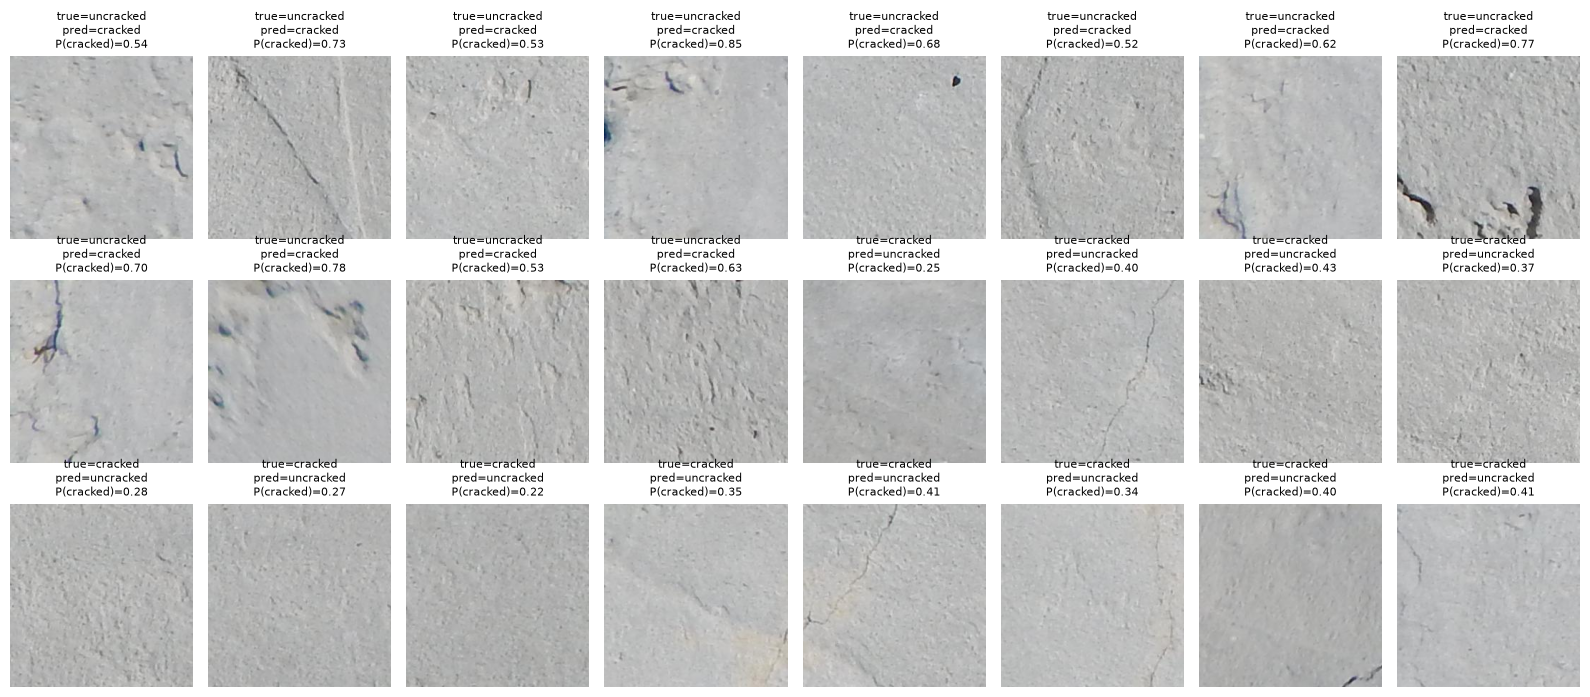

False positives: 134
False negatives: 230
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\validation_misclassified.png
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\group_validation_flip\misclassified_examples.json


In [102]:
validation_targets, validation_predictions, validation_probabilities = (
    collect_probability_diagnostics(model, val_loader, device)
)
false_positive_indices = [
    position
    for position, (target, prediction) in enumerate(
        zip(validation_targets, validation_predictions)
    )
    if target == 0 and prediction == 1
]
false_negative_indices = [
    position
    for position, (target, prediction) in enumerate(
        zip(validation_targets, validation_predictions)
    )
    if target == 1 and prediction == 0
]

error_positions = false_positive_indices[:12] + false_negative_indices[:12]
figure, axes = plt.subplots(3, 8, figsize=(16, 7))
for axis in axes.flat:
    axis.axis('off')
for axis, position in zip(axes.flat, error_positions):
    dataset_index = val_indices[position]
    image_path, target = train_full.samples[dataset_index]
    with Image.open(image_path) as image:
        axis.imshow(image.convert('RGB'))
    predicted_name = CLASS_NAMES[validation_predictions[position]]
    target_name = CLASS_NAMES[target]
    probability = validation_probabilities[position]
    axis.set_title(
        f'true={target_name}\npred={predicted_name}\nP(cracked)={probability:.2f}',
        fontsize=8,
    )

figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'validation_misclassified.png', dpi=160)
plt.show()

misclassified_summary = {
    'false_positive_count': len(false_positive_indices),
    'false_negative_count': len(false_negative_indices),
    'false_positive_examples': [
        train_full.samples[val_indices[position]][0]
        for position in false_positive_indices[:12]
    ],
    'false_negative_examples': [
        train_full.samples[val_indices[position]][0]
        for position in false_negative_indices[:12]
    ],
}
(OUTPUT_DIR / 'misclassified_examples.json').write_text(
    json.dumps(misclassified_summary, ensure_ascii=False, indent=2),
    encoding='utf-8',
)
print('False positives:', len(false_positive_indices))
print('False negatives:', len(false_negative_indices))
print('Saved:', OUTPUT_DIR / 'validation_misclassified.png')
print('Saved:', OUTPUT_DIR / 'misclassified_examples.json')